# E-Commerce Customer Churn Data Analysis
## overview
This project helps to extract insights from dataset that why people cancel their subscription and why they are in pause to active the subscription

**Dataset:** E-Commerce Churn Dataset 2025

**Tool:** Python(pandas,matplotlib,seaborn)

**Goal:** Identify patterns that predict customer churn


In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.ma.core import correlate

df = pd.read_csv('E Commerce Customer Insights and Churn Dataset.csv')
print('Loaded!',df.shape)

Loaded! (2000, 17)


In [76]:
df['signup_date']=pd.to_datetime(df['signup_date'],errors='coerce')
df['last_purchase_date']=pd.to_datetime(df['last_purchase_date'],errors='coerce')
df['order_date']=pd.to_datetime(df['order_date'],errors='coerce')

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   order_id             2000 non-null   object        
 1   customer_id          2000 non-null   object        
 2   age                  2000 non-null   int64         
 3   product_id           2000 non-null   object        
 4   country              2000 non-null   object        
 5   signup_date          2000 non-null   datetime64[ns]
 6   last_purchase_date   2000 non-null   datetime64[ns]
 7   cancellations_count  2000 non-null   int64         
 8   subscription_status  2000 non-null   object        
 9   order_date           2000 non-null   datetime64[ns]
 10  unit_price           2000 non-null   float64       
 11  quantity             2000 non-null   int64         
 12  purchase_frequency   2000 non-null   int64         
 13  preferred_category   2000 non-nul

In [79]:
churn_counts = df['subscription_status'].value_counts()
churn_counts

subscription_status
active       1204
cancelled     493
paused        303
Name: count, dtype: int64

## 1. Understanding Customer Churn
* Before analysis, we are going to look for the customer nuumbers who  are being fallen under the churned list

**Key question:** How many customer cancelled their subscription ?

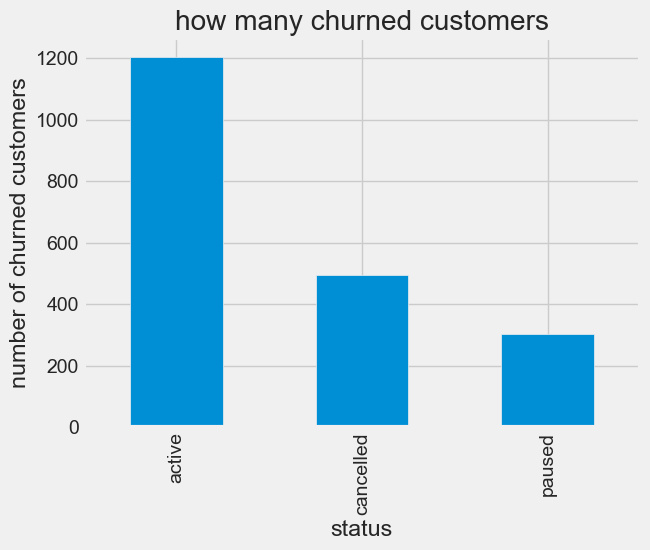

In [80]:
churn_counts.plot(kind='bar')
plt.title('how many churned customers')
plt.xlabel('status')
plt.ylabel('number of churned customers')
plt.style.use('fivethirtyeight')

plt.show()


## Findings 1
out of 2000 customers:

- **1,204** customers are active (about 60%)

- **493** customers churned (about 25%)

- **303** customers paused (about 15%)

**key insights:** 1 in 4 customers left the platform

the churned rate should be examined carefully.it requires immediate attention


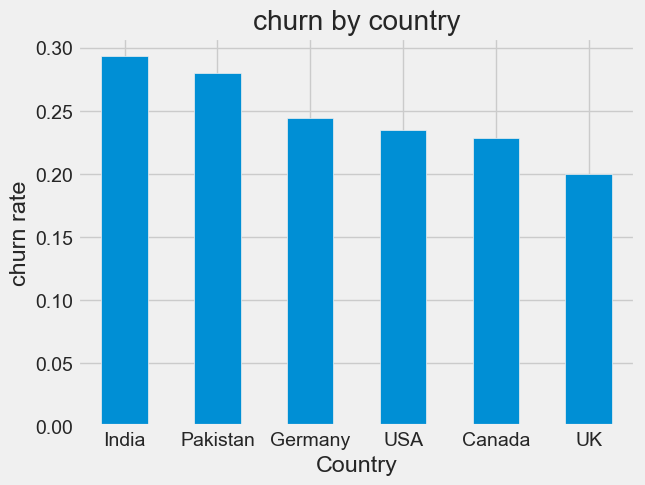

In [81]:
churn_by_country = df.groupby('country')['subscription_status'].apply(lambda  x:(x=='cancelled').mean())
churn_by_country.sort_values(ascending=False).plot(kind='bar')
plt.title('churn by country')
plt.xlabel('Country')
plt.ylabel('churn rate')
plt.xticks(rotation=0)
plt.show()

# findings 2

- **India** has the highest churn rate.

- **UK** has the lowest churn rate.

- **USA** & **UK** has almost same rates.only shows negligible differences

## findings 3
- I think people in term og buying beauty products are confused whether they are getting the authentic products or not. that's why this category customer churns a lot. but closer to both home and sports category.

- but Electronics category has comparatively  lower churn rates than others

**Key Insight:** Churn is spread almost equally across
all product categories. This suggests the churn problem
is not product-related. The business should focus on
customer experience and service quality instead of
specific product categories.

**Possible reason for Beauty churn:** Customers may
have concerns about product authenticity which
drives them to cancel.


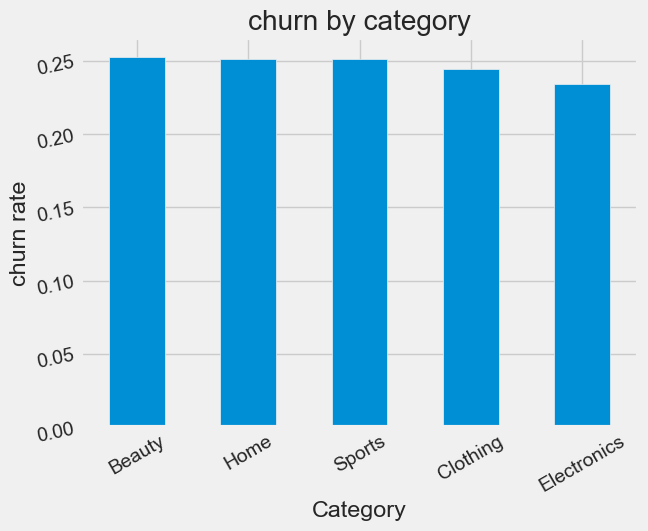

In [82]:
churn_by_category = df.groupby('category')['subscription_status'].apply(lambda  x:(x=='cancelled').mean())
churn_by_category.sort_values(ascending=False).plot(kind='bar')
plt.title('churn by category')
plt.xlabel('Category')
plt.ylabel('churn rate')
plt.xticks(rotation=30)
plt.yticks(rotation=12)
plt.show()

In [84]:
df['is_churned']=(df['subscription_status']=='cancelled').astype(int)

## findings 4
- About 50 age people churned
-
- Between 20-30 people do less cancel
-
- But the most active people lies between 60-70

**Key Insight:** Age does not strongly predict churn
as all age groups show similar patterns. However
younger customers (20-30) tend to stay longer
which suggests the platform appeals more to
younger audiences.


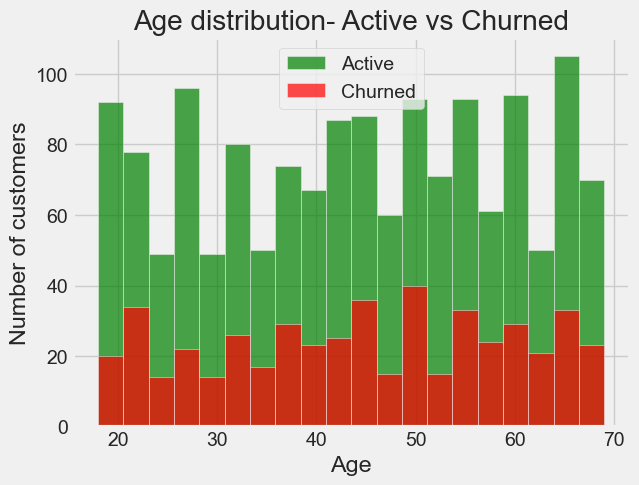

In [85]:
df[df['is_churned']==0]['age'].hist(bins=20,alpha=0.7,label='Active',color='green')
df[df['is_churned']==1]['age'].hist(bins=20,alpha=0.7,label='Churned',color='red')
plt.title('Age distribution- Active vs Churned')
plt.xlabel('Age')
plt.ylabel('Number of customers')
plt.legend()
plt.show()


## Findings 5 - Purchase Frequency vs Churn
- Active customers have a median purchase frequency of around **25**
- Churned customers have a median purchase frequency of around **27**

- Both groups show very similar distribution

**Key insights** Purchase frequency does NOT
predict churn in this dataset. Customers who
buy frequently still cancel at the same rate
as customers who buy rarely. This tells the
business that simply encouraging more purchases
will NOT reduce churn — there is a deeper
underlying issue causing customers to leave.

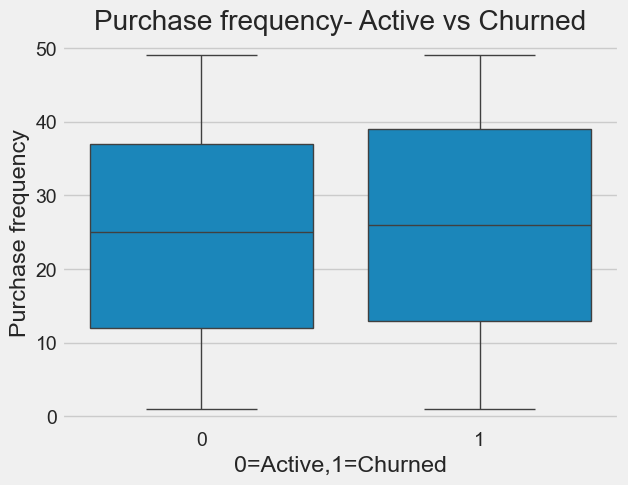

In [86]:
sns.boxplot(data=df,x='is_churned',y='purchase_frequency')
plt.title('Purchase frequency- Active vs Churned')
plt.xlabel('0=Active,1=Churned')
plt.ylabel('Purchase frequency')
plt.show()

## 6. Correlation Heatmap
This heatmap shows how all numeric columns
relate to each other. Values close to 1 mean
strong relationship, close to 0 means no relationship.

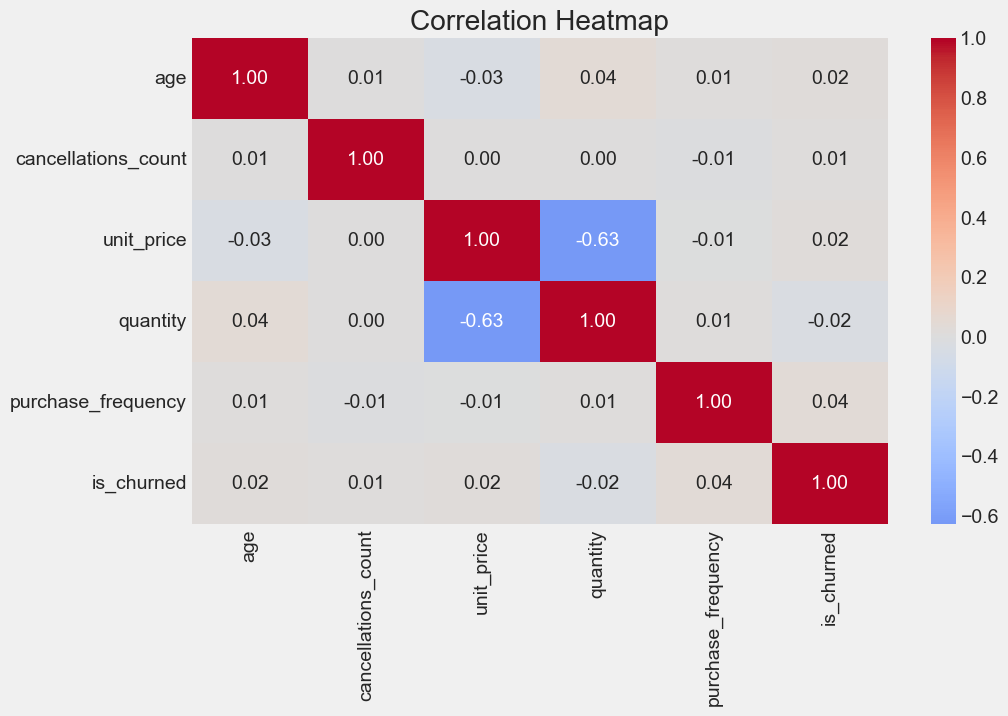

In [87]:
numeric_cols = ['age','cancellations_count','unit_price','quantity','purchase_frequency','is_churned']

plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols].corr(),
            annot=True,
            fmt = '.2f',
            cmap = 'coolwarm',
            center = 0)
plt.title('Correlation Heatmap')
plt.show()

## Heatmap Finding

- **unit_price and quantity = -0.63** strong negative
  relationship. Higher priced items are bought in
  lower quantities — expected consumer behavior.

- **All correlations with is_churned are near 0**
  confirming that no single numeric variable
  strongly predicts churn in this dataset.

**Key Insight:** Churn prediction requires looking
beyond simple numeric correlations. External factors
like customer satisfaction and service quality
likely play a bigger role.

# Conclusion

I think E- commerce platforms are still not be appropriate for middle aged people.as the technology advancement increases rapidly like a blink of an eye.so adaptibility with technology may cause problem to not being responsive on E-connerce platform specially when people cross 50.
### key insights
**  1 in 4 left the platform that means 25% churned
** india has the highest churned rate while Uk has the lowest churned rate
** Beauty category shows people have confusion from online platform if they provide authentic products to customer

# Recommendation
1.Focus retention efforts on **India** and **Pakistan** markets
2.Investigate **Beauty** category authenticity issues
3.make user friendly for middle aged people